# Keşifsel Veri Analizi

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Veri Yükleme

In [63]:
players = pd.read_csv('../data/raw/players.csv')
valuations = pd.read_csv('../data/raw/player_valuations.csv')
appearances = pd.read_csv('../data/raw/appearances.csv')
competitions = pd.read_csv('../data/raw/competitions.csv')
clubs = pd.read_csv('../data/raw/clubs.csv')

print("players:", players.shape)
print("valuations:", valuations.shape)
print("appearances:", appearances.shape)
print("competitions:", competitions.shape)
print("clubs:", clubs.shape)

players: (47702, 26)
valuations: (616377, 6)
appearances: (1862208, 13)
competitions: (67, 11)
clubs: (796, 17)


## 2. Veri İnceleme

In [64]:
print("=== PLAYERS tablosu özellikleri ===")
print(players.columns.tolist())
display(players.head(3))

print("=== VALUATIONS tablosu özellikleri ===")
print(valuations.columns.tolist())
display(valuations.head(3))

print("=== APPEARANCES tablosu özellikleri ===")
print(appearances.columns.tolist())
display(appearances.head(3))

print("=== COMPETITIONS tablosu özellikleri ===")
print(competitions.columns.tolist())
display(competitions.head(3))

print("=== CLUBS tablosu özellikleri ===")
print(clubs.columns.tolist())
display(clubs.head(3))

=== PLAYERS tablosu özellikleri ===
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09 00:00:00,Centre-Forward,Attack,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06 00:00:00,Goalkeeper,Goalkeeper,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30 00:00:00,Centre-Forward,Attack,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


=== VALUATIONS tablosu özellikleri ===
['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057.0,BE1
1,342216,2001-07-20,100000,Unknown,1241.0,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1


=== APPEARANCES tablosu özellikleri ===
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45


=== COMPETITIONS tablosu özellikleri ===
['competition_id', 'competition_code', 'name', 'sub_type', 'type', 'country_id', 'country_name', 'domestic_league_code', 'confederation', 'total_clubs', 'url']


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
0,A1,bundesliga,bundesliga,first_tier,domestic_league,127,Austria,A1,europa,12.0,https://www.transfermarkt.co.uk/bundesliga/sta...
1,AFAC,afc-asian-cup,afc-asian-cup,afc_asian_cup,national_team_competition,-1,NaN,NaN,asien,NaN,https://www.transfermarkt.co.uk/afc-asian-cup/...
2,AFCN,africa-cup-of-nations,africa-cup-of-nations,africa_cup_of_nations,national_team_competition,-1,NaN,NaN,afrika,NaN,https://www.transfermarkt.co.uk/africa-cup-of-...


=== CLUBS tablosu özellikleri ===
['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris Football Club,FR1,NaN,31,28.5,17,54.8,8,Stade Jean Bouin,19904,€-72.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,10010,esporte-clube-bahia,Esporte Clube Bahia,BRA1,NaN,32,26.2,6,18.8,3,Arena Fonte Nova,47364,+€8.14m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/esporte-clube-...


## 3. Veri Birleştirme ve Eksik Analizi

In [65]:
print("Birleştirme öncesi eksik kontrolü:")
print(players.isnull().sum())
print("Birleştirilmemiş veri boyutu:", players.shape)

Birleştirme öncesi eksik kontrolü:
player_id                                   0
first_name                               3095
last_name                                   0
name                                        0
last_season                                 0
current_club_id                             0
player_code                                 0
country_of_birth                         5162
city_of_birth                            4887
country_of_citizenship                    271
date_of_birth                              49
sub_position                              455
position                                    0
foot                                     5256
height_in_cm                             3756
contract_expiration_date                16488
agent_name                              22180
image_url                                   0
international_caps                      29979
international_goals                     29979
current_national_team_id                44611

In [66]:
# en güncel piyasa değerini alma
valuations['date'] = pd.to_datetime(valuations['date'])
latest_valuations = valuations.sort_values('date').groupby('player_id').last().reset_index()

# futbolcu başına maç istatistiklerini toplama
player_stats = appearances.groupby('player_id').agg(
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_minutes=('minutes_played', 'sum'),
    total_matches=('appearance_id', 'count'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_red_cards=('red_cards', 'sum')
).reset_index()

player_stats['goals_per_match'] = player_stats['total_goals'] / player_stats['total_matches']
player_stats['assists_per_match'] = player_stats['total_assists'] / player_stats['total_matches']
player_stats['minutes_per_match'] = player_stats['total_minutes'] / player_stats['total_matches']

# tabloları birleştirme
df = players[['player_id', 'date_of_birth', 'position', 'sub_position', 'foot', 'height_in_cm', 'country_of_citizenship']].copy()
df = df.merge(latest_valuations[['player_id', 'market_value_in_eur', 'player_club_domestic_competition_id']], on='player_id', how='inner')
df = df.merge(player_stats, on='player_id', how='left')

# yaş hesaplama
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['age'] = (pd.Timestamp('today') - df['date_of_birth']).dt.days // 365
df = df.drop(columns=['date_of_birth'])

In [67]:
print("Birleştirme sonrası eksik kontrolü:")
print(df.isnull().sum())
print("Birleştirilmiş veri boyutu:", df.shape)

Birleştirme sonrası eksik kontrolü:
player_id                                  0
position                                   0
sub_position                             124
foot                                    2883
height_in_cm                            2015
country_of_citizenship                   256
market_value_in_eur                        0
player_club_domestic_competition_id     1463
total_goals                            11585
total_assists                          11585
total_minutes                          11585
total_matches                          11585
total_yellow_cards                     11585
total_red_cards                        11585
goals_per_match                        11585
assists_per_match                      11585
minutes_per_match                      11585
age                                       33
dtype: int64
Birleştirilmiş veri boyutu: (39226, 18)


## 5. Temel İstatistikler

In [68]:
df.describe()

,player_id,height_in_cm,market_value_in_eur,total_goals,total_assists,total_minutes,total_matches,total_yellow_cards,total_red_cards,goals_per_match,assists_per_match,minutes_per_match,age
count,3.922600e+04,37211.000000,3.922600e+04,27641.000000,27641.000000,27641.000000,27641.000000,27641.000000,27641.000000,27641.000000,27641.000000,27641.000000,39193.000000
mean,4.167688e+05,182.144554,1.556696e+06,6.421186,5.053399,4616.499041,67.229044,9.805217,0.254984,0.062501,0.049288,58.382339,29.747838
std,3.311132e+05,7.355143,5.934682e+06,17.152380,11.386013,6514.583414,87.359749,15.029786,0.629959,0.100156,0.073374,23.930228,6.748158
min,1.000000e+01,17.000000,1.000000e+04,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,16.000000
25%,1.376250e+05,177.000000,1.000000e+05,0.000000,0.000000,344.000000,8.000000,1.000000,0.000000,0.000000,0.000000,42.857143,24.000000
50%,3.413085e+05,182.000000,2.750000e+05,1.000000,1.000000,1867.000000,31.000000,4.000000,0.000000,0.022901,0.023256,62.412698,29.000000
75%,6.296248e+05,187.000000,7.500000e+05,5.000000,5.000000,6292.000000,93.000000,13.000000,0.000000,0.087432,0.077381,77.688679,34.000000
max,1.516901e+06,210.000000,2.000000e+08,525.000000,224.000000,53667.000000,656.000000,147.000000,8.000000,2.000000,1.000000,120.000000,56.000000


## 6. Görselleştirmeler

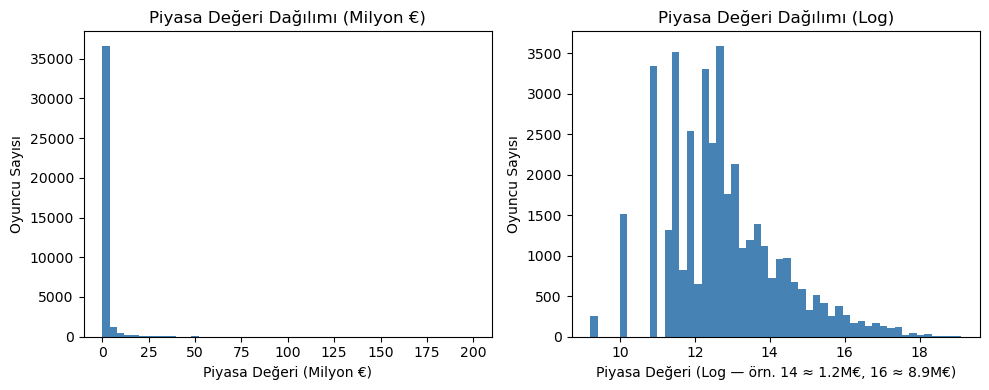

In [69]:
# piyasa değeri dağılımı
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['market_value_in_eur'] / 1_000_000, bins=50, color='steelblue')
plt.title('Piyasa Değeri Dağılımı (Milyon €)')
plt.xlabel('Piyasa Değeri (Milyon €)')
plt.ylabel('Oyuncu Sayısı')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['market_value_in_eur']), bins=50, color='steelblue')
plt.title('Piyasa Değeri Dağılımı (Log)')
plt.xlabel('Piyasa Değeri (Log — örn. 14 ≈ 1.2M€, 16 ≈ 8.9M€)')
plt.ylabel('Oyuncu Sayısı')

plt.tight_layout()
plt.savefig('../visuals/market_value_distribution.png')
plt.show()

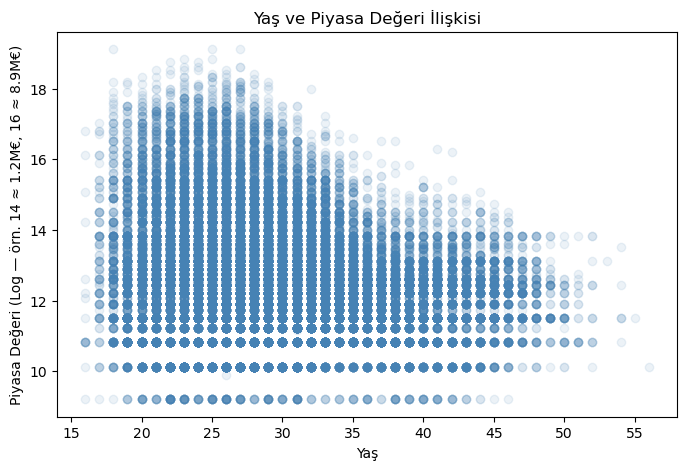

In [70]:
# yaş ve piyasa değeri ilişkisi
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], np.log1p(df['market_value_in_eur']), alpha=0.1, color='steelblue')
plt.title('Yaş ve Piyasa Değeri İlişkisi')
plt.xlabel('Yaş')
plt.ylabel('Piyasa Değeri (Log — örn. 14 ≈ 1.2M€, 16 ≈ 8.9M€)')
plt.savefig('../visuals/age_vs_value.png')
plt.show()

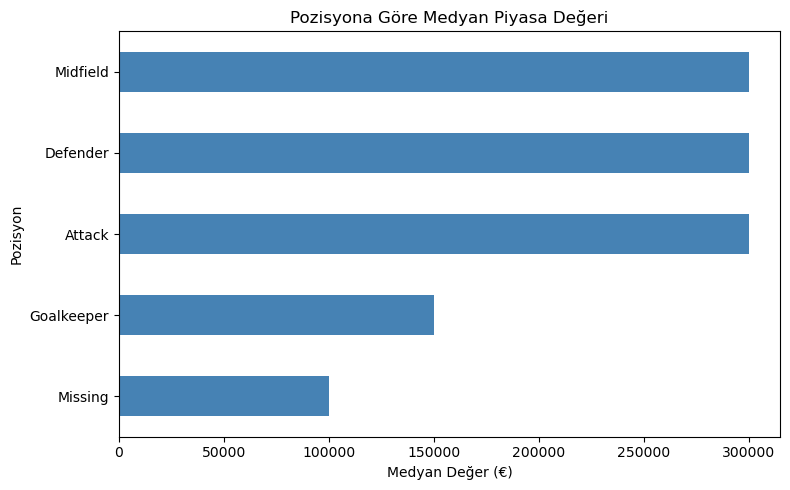

In [71]:
# pozisyona göre piyasa değeri
plt.figure(figsize=(8, 5))
df.groupby('position')['market_value_in_eur'].median().sort_values().plot(kind='barh', color='steelblue')
plt.title('Pozisyona Göre Medyan Piyasa Değeri')
plt.xlabel('Medyan Değer (€)')
plt.ylabel('Pozisyon')
plt.tight_layout()
plt.savefig('../visuals/position_vs_value.png')
plt.show()

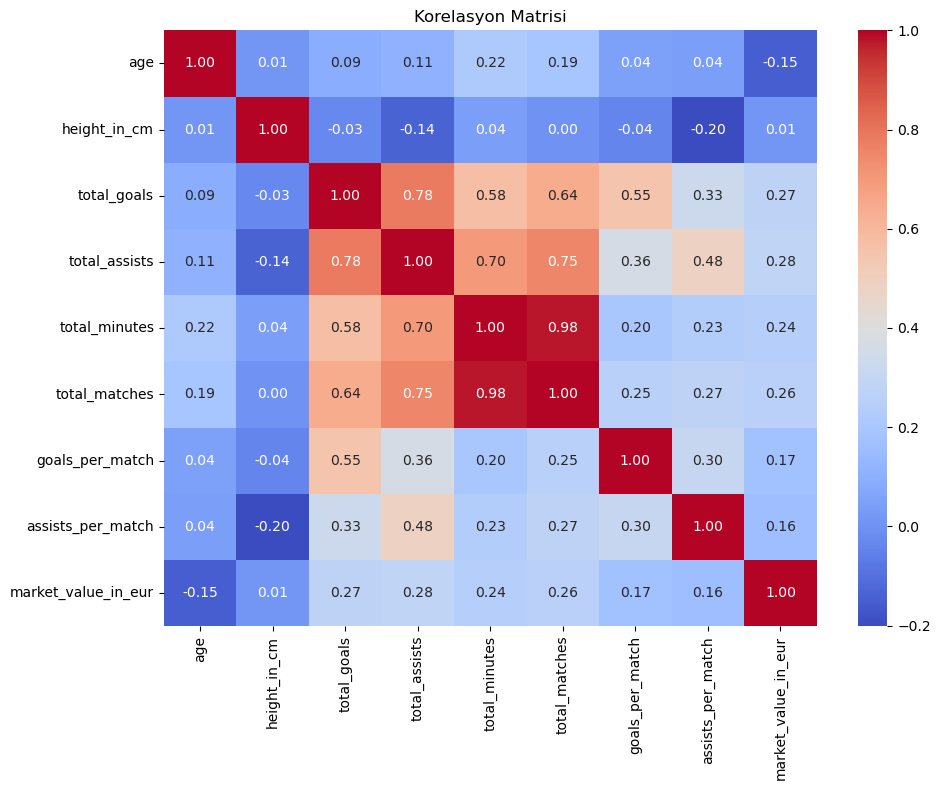

In [72]:
# korelasyon matrisi
numeric_cols = ['age', 'height_in_cm', 'total_goals', 'total_assists', 
                'total_minutes', 'total_matches', 'goals_per_match', 
                'assists_per_match', 'market_value_in_eur']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png')
plt.show()

## 7. Bulgular
- Birleştirme sonrası futbolcu sayısı 47702'den 39226'ya düşmüştür; piyasa değeri kaydı bulunmayan futbolcular elenmiştir. Ayrıca 11585 futbolcunun maç istatistiği bulunmamaktadır; bu futbolcular ön işleme aşamasında veri setinden çıkarılacaktır.
- Piyasa değeri sağa çarpık dağılım göstermektedir; futbolcuların büyük çoğunluğu 0-25 milyon € arasında değere sahipken az sayıda futbolcu çok yüksek değerlere ulaşmaktadır. Modellemede log dönüşümü uygulanacaktır.
- Futbolcu piyasa değeri 25-28 yaş arasında zirveye ulaşmakta, sonrasında yaşla birlikte düşme eğilimi göstermektedir. Yaş ile piyasa değeri arasındaki negatif korelasyon (−0.15) bu bulguyu desteklemektedir.
- Pozisyonlar arasında belirgin bir piyasa değeri farkı gözlemlenmemiştir; kaleciler diğer pozisyonlara kıyasla görece düşük medyan değere sahiptir.
- Toplam süre (total_minutes) ve toplam maç sayısı (total_matches) arasında 0.98 korelasyon tespit edilmiştir; çoklu doğrusal bağlantı sorununu önlemek için biri ön işleme aşamasında çıkarılacaktır.
- Boy (height_in_cm) ve maç başına gol/asist (goals_per_match, assists_per_match) gibi değişkenler piyasa değeriyle zayıf ilişki göstermektedir (sırasıyla 0.01, 0.17, 0.16).

## 8. Veri Kaydetme

In [73]:
# birleştirilmiş tabloyu kaydetme
df.to_csv('../data/processed/merged.csv', index=False)
print("Keşifsel veri analizi sonucu veri boyutu:", df.shape)

Keşifsel veri analizi sonucu veri boyutu: (39226, 18)
